# 스프린트 미션 6 (***X-Ray 사진을 바탕으로 한 폐렴 환자 구분***)

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from torchvision import transforms, datasets, models
from torchvision.transforms import v2
import math
import torchvision.transforms.functional as TF
import torch.nn.functional as F

## 데이터 확인 및 전처리
### 데이터 로드

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print("Dataset path:", path)

Dataset path: C:\Users\Good-PC\.cache\kagglehub\datasets\paultimothymooney\chest-xray-pneumonia\versions\2


### 모델 구동 환경 설정

In [ ]:
# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


### 데이터 경로 설정

In [ ]:
train_dir = os.path.join(path, "chest_xray", "train")
val_dir = os.path.join(path, "chest_xray", "val")
test_dir = os.path.join(path, "chest_xray", "test")

In [ ]:
transforms = v2.Compose(
    [
        v2.Resize((224, 224)),
        v2.ToImage(),
        v2.ToDtype(dtype=torch.float32, scale=True),
    ]
)

# 데이터셋 로드
train_dataset = datasets.ImageFolder(train_dir, transform=transforms)

# DataLoader 생성
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# 클래스 확인
class_names = train_dataset.classes
print("Class names:", class_names)

Class names: ['NORMAL', 'PNEUMONIA']


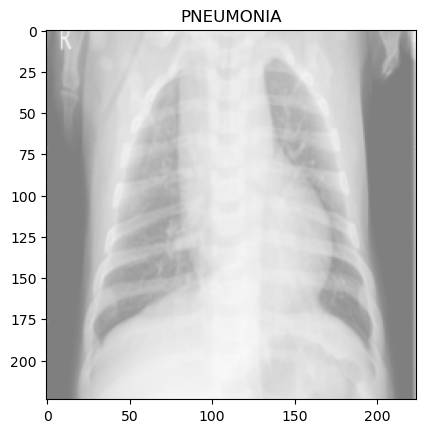

In [ ]:
# 데이터 로더에서 배치 가져오기 (train)
images, labels = next(iter(train_loader))

# 이미지를 디스플레이
def imshow(img, title):
    img = img / 2 + 0.5  # 정규화 복원
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.title(title)
    plt.show()

# 첫 번째 배치의 첫 번째 이미지 시각화
imshow(images[0], title=class_names[labels[0]])

### 데이터 전처리
- 이미지넷 전이학습 모델을 구동할 예정이므로 이미지넷 평균과 표준편차로 정규화 진행.
- 훈련 데이터 증강 -> X-ray 이미지에서 주로 좌우반전은 허용 가능

In [ ]:
# 데이터 전처리 정의

imagenet_mean = [0.485, 0.456, 0.406]   # 이미지넷 평균
imagenet_std  = [0.229, 0.224, 0.225]

data_transforms = {
    'train': v2.Compose([
        v2.Resize((224, 224)),                # 이미지 크기 조정
        v2.RandomHorizontalFlip(p=0.5),      # 좌우 반전 (보통 X-Ray 이미지에선 좌우 반전은 허용한다고 함)
        # v2.RandomCrop((200, 200)),           # 랜덤 크롭 (200x200)
        # v2.RandomRotation(20),              # 랜덤 회전 (-20도 ~ 20도)
        v2.ToTensor(),                       # 텐서로 변환
        v2.Normalize(mean=imagenet_mean, std=imagenet_std)           # 정규화
    ]),
    'val': v2.Compose([
        v2.Resize((224, 224)),               # 이미지 크기 조정
        v2.ToTensor(),                       # 텐서로 변환
        v2.Normalize(mean=imagenet_mean, std=imagenet_std)           # 정규화
    ]),
    'test': v2.Compose([
        v2.Resize((224, 224)),               # 이미지 크기 조정
        v2.ToTensor(),                       # 텐서로 변환
        v2.Normalize(mean=imagenet_mean, std=imagenet_std)           # 정규화
    ])
}

# 데이터셋 로드
train_dataset = datasets.ImageFolder(train_dir, transform=data_transforms['train'])
val_dataset = datasets.ImageFolder(val_dir, transform=data_transforms['val'])
test_dataset = datasets.ImageFolder(test_dir, transform=data_transforms['test'])

# DataLoader 생성
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of validation samples: {len(val_dataset)}")
print(f"Number of test samples: {len(test_dataset)}")

Number of training samples: 5216
Number of validation samples: 16
Number of test samples: 624


c:\Users\Good-PC\anaconda3\Lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


## 전이학습 (DenseNet 121)

In [ ]:
# 사전학습된 DenseNet121 불러오기
densenet = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)

for param in densenet.features.parameters():
    param.requires_grad = False

In [ ]:
num_features = densenet.classifier.in_features  # 1024
densenet.classifier = nn.Linear(num_features, 2)

densenet = densenet.to(device)

In [ ]:
# loss함수와 optim 설정

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, densenet.parameters()), lr=0.00001)

### DenseNet 모델 정의

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    total_correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)  # [B, 2]

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

        _, preds = torch.max(outputs, 1)
        total_correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, total_correct / total


def eval_one_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    total_correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            total_correct += (preds == labels).sum().item()
            total += labels.size(0)

    return total_loss / total, total_correct / total



### 모델 학습

In [ ]:
epochs = 10

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(densenet, train_loader, criterion, optimizer, device)
    val_loss, val_acc     = eval_one_epoch(densenet, val_loader, criterion, device)

    print(f"[{epoch+1}/{epochs}] "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")


[1/10] Train Loss: 0.4824, Acc: 0.7684 | Val Loss: 0.6552, Acc: 0.5625
[2/10] Train Loss: 0.3515, Acc: 0.8587 | Val Loss: 0.4576, Acc: 0.6875
[3/10] Train Loss: 0.2863, Acc: 0.9009 | Val Loss: 0.4010, Acc: 0.8125
[4/10] Train Loss: 0.2488, Acc: 0.9132 | Val Loss: 0.3454, Acc: 0.8750
[5/10] Train Loss: 0.2264, Acc: 0.9233 | Val Loss: 0.3456, Acc: 0.8750
[6/10] Train Loss: 0.2097, Acc: 0.9275 | Val Loss: 0.3063, Acc: 0.8750
[7/10] Train Loss: 0.1946, Acc: 0.9325 | Val Loss: 0.3052, Acc: 0.9375
[8/10] Train Loss: 0.1877, Acc: 0.9329 | Val Loss: 0.2684, Acc: 0.9375
[9/10] Train Loss: 0.1814, Acc: 0.9340 | Val Loss: 0.2723, Acc: 0.9375
[10/10] Train Loss: 0.1710, Acc: 0.9388 | Val Loss: 0.2553, Acc: 0.9375


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report

def test_model(loaded_model, loader, device):
    loaded_model.eval()
    all_preds = []
    all_labels = []

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = loaded_model(images)
            _, preds = torch.max(outputs, 1)

            # Accuracy 카운트
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            # 전체 저장
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    # numpy로 변환
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    # Accuracy 계산
    accuracy = correct / total

    return all_labels, all_preds, accuracy


In [ ]:
true_labels, pred_labels, test_acc = test_model(loaded_model, test_loader, device)
precision = precision_score(true_labels, pred_labels, average='binary')
recall    = recall_score(true_labels, pred_labels, average='binary')
f1        = f1_score(true_labels, pred_labels, average='binary')
cm = confusion_matrix(true_labels, pred_labels)

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:\n")
print(classification_report(true_labels, pred_labels, target_names=['NORMAL', 'PNEUMONIA']))


Test Accuracy: 0.8478
Precision : 0.8118
Recall    : 0.9846
F1-score  : 0.8899

Confusion Matrix:
[[145  89]
 [  6 384]]

Classification Report:

              precision    recall  f1-score   support

      NORMAL       0.96      0.62      0.75       234
   PNEUMONIA       0.81      0.98      0.89       390

    accuracy                           0.85       624
   macro avg       0.89      0.80      0.82       624
weighted avg       0.87      0.85      0.84       624



### 모델 저장

In [ ]:
# 저장
# torch.save(densenet.state_dict(), "densenet_model_epoch(10).pth")

# 불러오기
# from torchvision import models
# import torch.nn as nn

# 모델 구조 생성
loaded_model = models.densenet121(weights=None)  # pretrained 불필요
num_features = loaded_model.classifier.in_features
loaded_model.classifier = nn.Linear(num_features, 2)

# 가중치 로드
loaded_model.load_state_dict(torch.load("densenet_model.pth", map_location='cuda'))
loaded_model = loaded_model.to(device)
loaded_model.eval()


DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

### DenseNet 모델 Finetunning ver.

In [ ]:
# 1) 일단 전체 features는 기본적으로는 Freeze 상태라고 가정
for param in densenet.features.parameters():
    param.requires_grad = False

# 2) 그 중에서 denseblock4와 norm5만 다시 풀어주기
for name, param in densenet.features.named_parameters():
    if "denseblock4" in name or "norm5" in name:
        param.requires_grad = True
        # 디버깅용으로 보고 싶으면:
        # print("Unfreeze:", name)

In [ ]:
trainable_params = filter(lambda p: p.requires_grad, densenet.parameters())
optimizer_ft = torch.optim.Adam(
    trainable_params,
    lr=1e-5,       # 기존보다 더 작게
    weight_decay=1e-4
)

In [ ]:
epochs_ft = 10

for epoch in range(epochs_ft):
    train_loss, train_acc = train_one_epoch(densenet, train_loader, criterion, optimizer_ft, device)
    val_loss, val_acc     = eval_one_epoch(densenet, val_loader, criterion, device)

    print(f"[Fine-Tune {epoch+1}/{epochs_ft}] "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

[Fine-Tune 1/10] Train Loss: 0.1477, Acc: 0.9442 | Val Loss: 0.2106, Acc: 1.0000
[Fine-Tune 2/10] Train Loss: 0.1194, Acc: 0.9582 | Val Loss: 0.1845, Acc: 1.0000
[Fine-Tune 3/10] Train Loss: 0.0957, Acc: 0.9653 | Val Loss: 0.2000, Acc: 0.9375
[Fine-Tune 4/10] Train Loss: 0.0845, Acc: 0.9734 | Val Loss: 0.1820, Acc: 0.9375
[Fine-Tune 5/10] Train Loss: 0.0793, Acc: 0.9743 | Val Loss: 0.1792, Acc: 0.9375
[Fine-Tune 6/10] Train Loss: 0.0710, Acc: 0.9776 | Val Loss: 0.2065, Acc: 0.9375
[Fine-Tune 7/10] Train Loss: 0.0618, Acc: 0.9806 | Val Loss: 0.2372, Acc: 0.9375
[Fine-Tune 8/10] Train Loss: 0.0554, Acc: 0.9827 | Val Loss: 0.1690, Acc: 0.9375
[Fine-Tune 9/10] Train Loss: 0.0493, Acc: 0.9858 | Val Loss: 0.2538, Acc: 0.9375
[Fine-Tune 10/10] Train Loss: 0.0438, Acc: 0.9885 | Val Loss: 0.2409, Acc: 0.9375


In [ ]:
true_labels, pred_labels, test_acc = test_model(densenet, test_loader, device)
precision = precision_score(true_labels, pred_labels, average='binary')
recall    = recall_score(true_labels, pred_labels, average='binary')
f1        = f1_score(true_labels, pred_labels, average='binary')

print(f"[After Fine-Tuning] Test Accuracy: {test_acc:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")

print("\nClassification Report:\n")
print(classification_report(true_labels, pred_labels, target_names=['NORMAL', 'PNEUMONIA']))

[After Fine-Tuning] Test Accuracy: 0.8173
Precision : 0.7749
Recall    : 0.9974
F1-score  : 0.8722

Classification Report:

              precision    recall  f1-score   support

      NORMAL       0.99      0.52      0.68       234
   PNEUMONIA       0.77      1.00      0.87       390

    accuracy                           0.82       624
   macro avg       0.88      0.76      0.78       624
weighted avg       0.86      0.82      0.80       624



### 모델 저장 Finetunning ver.

In [ ]:
# 저장
torch.save(densenet.state_dict(), "densenet_model_ft_1.pth")


# 불러오기
# model = models.densenet121(weights=None)   # pretrained 필요 없음

# model.classifier = nn.Linear(model.classifier.in_features, 2)

# model.load_state_dict(torch.load("densenet121_ft.pth", map_location=device))

# model.eval()

전체 Accuracy: 0.8173 (약 82%) → 오히려 떨어짐

파인튜닝 전 ≈ 0.85
파인튜닝 후 ≈ 0.82

기존보다 정확도가 낮아짐. -> 과적합 의심.


  
PNEUMONIA (양성 / 질병)

Recall = 1.00
→ 폐렴 환자를 단 한 명도 놓치지 않았음.
→ 의료적으로는 '민감도 100%'라는 매우 중요한 장점.

Precision = 0.77
→ 폐렴이라고 부른 사람 중 23%는 actually NORMAL
→ 즉, 과진단이 심해짐.


"폐렴을 절대로 놓치지 않겠다!" 라는 방향으로 Fine-Tuning됨. → 모델이 **폐렴에 과도하게 민감해진 상태**


---



의료적 관점에서는…
✔ 좋은 점

폐렴 환자를 절대 놓치지 않는다 (recall 1.00)

의료 스크리닝 시스템에서 false negative=0은 매우 큰 장점

❌ 문제점

정상 환자를 너무 많이 폐렴으로 오진 (과잉 진단)

실제 병원에서 이런 모델은 추가 검사 비용 증가, 불필요한 불안 유발 문제를 초래

### DenseNet 모델 Finetunning ver2.

1. enseBlock4 대신 더 적은 레이어만 Fine-Tuning  
ex) transition3 이후 몇 개 conv만 풀기 → 성능이 더 안정적  


In [ ]:
# --- 1. 우선 전체 features는 다시 Freeze ---
for param in densenet.features.parameters():
    param.requires_grad = False

# --- 2. classifier(마지막 FC)는 계속 학습하게 둡니다 ---
for param in densenet.classifier.parameters():
    param.requires_grad = True


In [ ]:
# --- 3. features 중에서도 "맨 끝 일부"만 풀기 ---
for name, param in densenet.features.named_parameters():
    # 마지막 두 레이어(denselayer15, denselayer16) + 최종 norm5만 풀기
    if ("denseblock4.denselayer15" in name or
        "denseblock4.denselayer16" in name or
        "norm5" in name):
        param.requires_grad = True
        # 디버깅용으로 어느 파라미터가 열렸는지 보고 싶으면:
        # print("Unfreeze:", name)


2. Class weights 조절하기   
NORMAL recall 올리기 위해:

In [ ]:
# Normal 쪽 racall을 조금 더 보정하기 위한 가중치 조정.
# Normal: index 0, PNEUMONIA: index 1

class_weights = torch.tensor([1.5, 1.0], device=device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Normal을 잘못 맞추면 loss를 더 많이 먹음 →
# 모델이 Normal도 더 신경 쓰게 됨 → Normal recall 올라갈 가능성 ↑

In [ ]:
trainable_params = filter(lambda p: p.requires_grad, densenet.parameters())

optimizer_ft = torch.optim.Adam(
    trainable_params,
    lr=1e-5,
    weight_decay=1e-4
)

In [ ]:
epochs_ft_2 = 10

for epoch in range(epochs_ft_2):
    train_loss, train_acc = train_one_epoch(densenet, train_loader, criterion, optimizer_ft, device)
    val_loss, val_acc     = eval_one_epoch(densenet, val_loader, criterion, device)

    print(f"[FT small {epoch+1}/{epochs_ft_2}] "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

[FT small 1/10] Train Loss: 0.0457, Acc: 0.9889 | Val Loss: 0.2203, Acc: 0.9375
[FT small 2/10] Train Loss: 0.0438, Acc: 0.9883 | Val Loss: 0.2669, Acc: 0.9375
[FT small 3/10] Train Loss: 0.0401, Acc: 0.9896 | Val Loss: 0.2925, Acc: 0.9375
[FT small 4/10] Train Loss: 0.0359, Acc: 0.9923 | Val Loss: 0.1571, Acc: 0.9375
[FT small 5/10] Train Loss: 0.0391, Acc: 0.9893 | Val Loss: 0.1711, Acc: 0.9375
[FT small 6/10] Train Loss: 0.0392, Acc: 0.9875 | Val Loss: 0.1754, Acc: 0.9375
[FT small 7/10] Train Loss: 0.0374, Acc: 0.9916 | Val Loss: 0.1744, Acc: 0.9375
[FT small 8/10] Train Loss: 0.0345, Acc: 0.9914 | Val Loss: 0.2325, Acc: 0.9375
[FT small 9/10] Train Loss: 0.0355, Acc: 0.9916 | Val Loss: 0.2761, Acc: 0.9375
[FT small 10/10] Train Loss: 0.0348, Acc: 0.9904 | Val Loss: 0.1965, Acc: 0.9375


In [ ]:
true_labels, pred_labels, test_acc = test_model(densenet, test_loader, device)

precision = precision_score(true_labels, pred_labels, average='binary')
recall    = recall_score(true_labels, pred_labels, average='binary')
f1        = f1_score(true_labels, pred_labels, average='binary')

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")
print("\nClassification Report:\n")
print(classification_report(true_labels, pred_labels, target_names=['NORMAL', 'PNEUMONIA']))

Test Accuracy: 0.8526
Precision : 0.8104
Recall    : 0.9974
F1-score  : 0.8943

Classification Report:

              precision    recall  f1-score   support

      NORMAL       0.99      0.61      0.76       234
   PNEUMONIA       0.81      1.00      0.89       390

    accuracy                           0.85       624
   macro avg       0.90      0.80      0.83       624
weighted avg       0.88      0.85      0.84       624



### 모델 저장 Finetunning ver2.

In [ ]:
# 저장
torch.save(densenet.state_dict(), "densenet_model_last.pth")


# 불러오기
# model = models.densenet121(weights=None)   # pretrained 필요 없음
# model.classifier = nn.Linear(model.classifier.in_features, 2)
# model.load_state_dict(torch.load("densenet121_ft.pth", map_location=device))
# model.eval()

### DenseNet Full Finetunning ver

In [ ]:
# DenseNet121 전체 레이어 풀기 (Full Fine-Tune)

for param in densenet.parameters():
    param.requires_grad = True

In [ ]:
# 손실함수
class_weights = torch.tensor([1.5, 1.0])
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
# 최적화
optimizer_full = torch.optim.Adam(
    densenet.parameters(),
    lr=1e-5,
    weight_decay=1e-4
)

In [ ]:
epochs_full_ft = 10   # 3~5로 시작, 이후 더 늘릴지 판단

for epoch in range(epochs_full_ft):
    train_loss, train_acc = train_one_epoch(densenet, train_loader, criterion, optimizer_full, device)
    val_loss, val_acc     = eval_one_epoch(densenet, val_loader, criterion, device)

    print(f"[Full FT {epoch+1}/{epochs_full_ft}] "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

[Full FT 1/10] Train Loss: 0.3002, Acc: 0.9091 | Val Loss: 0.3176, Acc: 0.8750
[Full FT 2/10] Train Loss: 0.1101, Acc: 0.9705 | Val Loss: 0.4125, Acc: 0.7500
[Full FT 3/10] Train Loss: 0.0822, Acc: 0.9768 | Val Loss: 0.4322, Acc: 0.8125
[Full FT 4/10] Train Loss: 0.0559, Acc: 0.9858 | Val Loss: 0.2590, Acc: 0.8750
[Full FT 5/10] Train Loss: 0.0421, Acc: 0.9914 | Val Loss: 0.2627, Acc: 0.8750
[Full FT 6/10] Train Loss: 0.0330, Acc: 0.9904 | Val Loss: 0.1944, Acc: 0.8750
[Full FT 7/10] Train Loss: 0.0290, Acc: 0.9933 | Val Loss: 0.1403, Acc: 0.9375
[Full FT 8/10] Train Loss: 0.0194, Acc: 0.9964 | Val Loss: 0.2524, Acc: 0.8750
[Full FT 9/10] Train Loss: 0.0140, Acc: 0.9975 | Val Loss: 0.2991, Acc: 0.8750
[Full FT 10/10] Train Loss: 0.0111, Acc: 0.9981 | Val Loss: 0.1332, Acc: 0.8750


In [ ]:
true_labels, pred_labels, test_acc = test_model(densenet, test_loader, device)

precision = precision_score(true_labels, pred_labels, average='binary')
recall    = recall_score(true_labels, pred_labels, average='binary')
f1        = f1_score(true_labels, pred_labels, average='binary')
cm = confusion_matrix(true_labels, pred_labels)

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:\n")
print(classification_report(true_labels, pred_labels, target_names=['NORMAL', 'PNEUMONIA']))

Test Accuracy: 0.8413
Precision : 0.7988
Recall    : 0.9974
F1-score  : 0.8871

Confusion Matrix:
[[136  98]
 [  1 389]]

Classification Report:

              precision    recall  f1-score   support

      NORMAL       0.99      0.58      0.73       234
   PNEUMONIA       0.80      1.00      0.89       390

    accuracy                           0.84       624
   macro avg       0.90      0.79      0.81       624
weighted avg       0.87      0.84      0.83       624



In [ ]:
torch.save(densenet.state_dict(), "densenet_fullFT.pth")

### 각 모델 별 결과 시각화

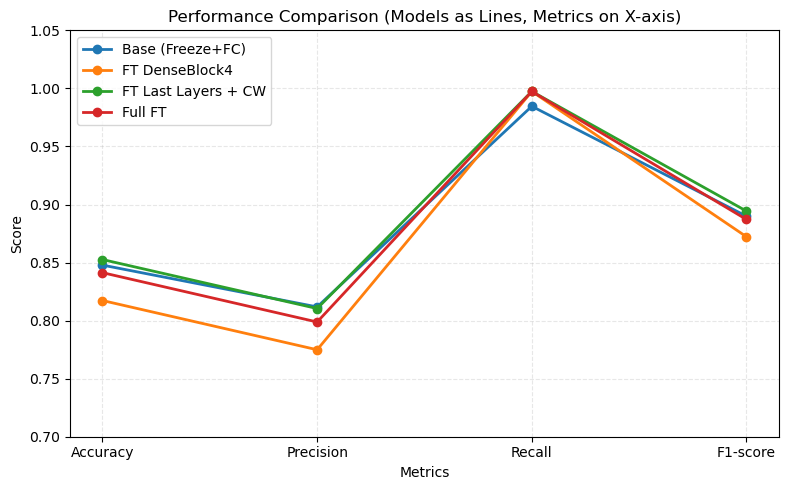

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1) 모델별 지표 정리
data = {
    "Model": [
        "Base (Freeze+FC)",
        "FT DenseBlock4",
        "FT Last Layers + CW",
        "Full FT"
    ],
    "Accuracy":  [0.8478, 0.8173, 0.8526, 0.8413],
    "Precision": [0.8118, 0.7749, 0.8104, 0.7988],
    "Recall":    [0.9846, 0.9974, 0.9974, 0.9974],
    "F1-score":  [0.8899, 0.8722, 0.8943, 0.8871],
}

df = pd.DataFrame(data)
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]

model_scores = {
    "Base (Freeze+FC)":     [0.8478, 0.8118, 0.9846, 0.8899],
    "FT DenseBlock4":       [0.8173, 0.7749, 0.9974, 0.8722],
    "FT Last Layers + CW":  [0.8526, 0.8104, 0.9974, 0.8943],
    "Full FT":              [0.8413, 0.7988, 0.9974, 0.8871],
}

plt.figure(figsize=(8, 5))

# 2) 각 모델이 하나의 라인이 되도록 plot
for model_name, scores in model_scores.items():
    plt.plot(metrics, scores, marker='o', linewidth=2, label=model_name)

# 3) 그래프 스타일
plt.ylim(0.7, 1.05)
plt.ylabel("Score")
plt.xlabel("Metrics")
plt.title("Performance Comparison (Models as Lines, Metrics on X-axis)")
plt.grid(linestyle="--", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 각 모델 별 결과 확인
팀원 별로 각자 전이학습 모델을 선택하여 구동해보았으며 각 모델별 Frozen, Partial, Full FT 결과를 취합하여 시각화

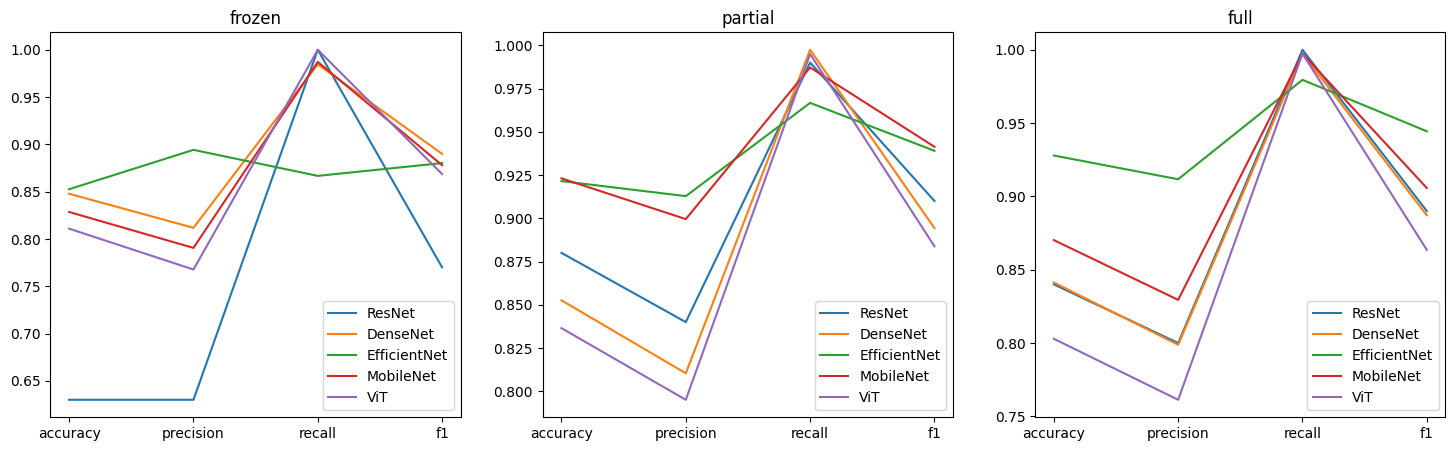

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import json

with open("mission6_results.json", "r", encoding="utf-8") as f:
    data = json.load(f)

model_list = ["ResNet", "DenseNet", "EfficientNet", "MobileNet", "ViT"]
tuning_list = ["frozen", "partial", "full"]
score_list = ["accuracy", "precision", "recall", "f1"]

fig, axs=plt.subplots(1,3,figsize=(18,5))

for i, tuning in enumerate(tuning_list):

    for model in model_list:
        temp = []
        for score in score_list:
            temp.append(data[model][tuning][score])
        axs[i].plot(np.arange(0,4), temp, label=model)
    axs[i].set_title(tuning)
    axs[i].set_xticks([0,1,2,3], score_list)
    axs[i].legend(loc="lower right")

plt.show()